In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import json

plt.style.use("seaborn-v0_8")

In [2]:
df_model = pd.read_csv("../data/pasig_clean_for_model.csv")

# Ensure datetime is in datetime format
df_model["datetime"] = pd.to_datetime(df_model["datetime"], errors="coerce")

df_model.head()

,temperature_2m_mean,temperature_2m_min,shortwave_radiation_sum,daylight_duration,sunshine_duration,et0_fao_evapotranspiration,rain_sum,precipitation_sum,wind_speed_10m_max,wind_gusts_10m_max,month,apparent_temperature_max,datetime
0,26.3,22.8,16.80,40601.74,36354.61,3.60,3.0,3.0,18.5,56.2,1,34.1,2020-01-01
1,26.7,22.9,19.18,40613.83,36596.39,4.24,0.1,0.1,15.6,51.1,1,34.3,2020-01-02
2,25.8,21.8,19.77,40626.99,36371.84,4.38,0.0,0.0,17.6,39.2,1,32.6,2020-01-03
3,25.5,20.8,18.11,40641.20,36672.16,4.04,0.0,0.0,16.3,37.1,1,33.4,2020-01-04
4,26.1,22.7,19.31,40656.43,36598.13,4.50,0.0,0.0,21.3,46.4,1,31.1,2020-01-05


In [3]:
model_path = "../models/rf_pasig_apparent_temp.pkl"
rf_model = joblib.load(model_path)
print("Loaded model from:", model_path)


Loaded model from: ../models/rf_pasig_apparent_temp.pkl


In [4]:
# Load feature list (to ensure correct column order)
with open("../models/feature_list.json", "r") as f:
    feature_names = json.load(f)

feature_names

['temperature_2m_mean',
 'temperature_2m_min',
 'shortwave_radiation_sum',
 'daylight_duration',
 'sunshine_duration',
 'et0_fao_evapotranspiration',
 'rain_sum',
 'precipitation_sum',
 'wind_speed_10m_max',
 'wind_gusts_10m_max',
 'month']

In [5]:
if "month" not in df_model.columns:
    df_model["month"] = df_model["datetime"].dt.month

# Compute average feature values per month (1–12)
monthly_feature_means = df_model.groupby("month")[feature_names].mean()

monthly_feature_means

,temperature_2m_mean,temperature_2m_min,shortwave_radiation_sum,daylight_duration,sunshine_duration,et0_fao_evapotranspiration,rain_sum,precipitation_sum,wind_speed_10m_max,wind_gusts_10m_max,month
month,,,,,,,,,,,
1,25.757527,22.534409,15.987957,40932.257849,33839.982688,3.519194,2.377957,2.377957,13.733333,33.298925,1.0
2,26.296471,22.530000,18.791882,42001.359353,36006.296824,4.315588,1.991765,1.991765,16.252941,37.915294,2.0
3,27.915648,23.681720,21.364138,43403.709570,39392.880186,5.137376,1.398740,1.398740,16.536559,38.536022,3.0
4,28.941333,24.764667,22.488800,44872.463733,40127.174867,5.550333,1.951333,1.951333,16.916667,37.776000,4.0
5,29.519355,25.893548,22.194065,46098.407548,39287.399419,5.360323,5.838710,5.838710,16.616129,37.965806,5.0
6,28.043333,25.192000,20.798467,46707.481133,37692.111400,4.458400,7.998000,7.998000,13.695333,32.580000,6.0
7,27.403871,24.830968,18.385226,46413.382839,31468.438065,3.910710,11.985161,11.985161,14.789677,34.598710,7.0
8,27.085161,24.810968,18.718581,45356.780710,32148.637484,3.859871,9.289032,9.289032,14.720000,33.856129,8.0
9,26.933333,24.546667,17.878800,43959.438467,30351.161400,3.673600,11.796667,11.796667,13.810000,32.574000,9.0


In [6]:
# Generate daily dates from 2025-04-01 to 2025-12-31
future_dates = pd.date_range(start="2025-04-01", end="2025-12-31", freq="D")

future_rows = []

for dt in future_dates:
    m = dt.month
    # Get typical weather features for that month
    avg_row = monthly_feature_means.loc[m].copy()
    avg_row["month"] = m  # ensure month is correct
    future_rows.append(avg_row)

# Build DataFrame of future features
X_future = pd.DataFrame(future_rows, index=future_dates)
X_future.head()

,temperature_2m_mean,temperature_2m_min,shortwave_radiation_sum,daylight_duration,sunshine_duration,et0_fao_evapotranspiration,rain_sum,precipitation_sum,wind_speed_10m_max,wind_gusts_10m_max,month
2025-04-01,28.941333,24.764667,22.4888,44872.463733,40127.174867,5.550333,1.951333,1.951333,16.916667,37.776,4.0
2025-04-02,28.941333,24.764667,22.4888,44872.463733,40127.174867,5.550333,1.951333,1.951333,16.916667,37.776,4.0
2025-04-03,28.941333,24.764667,22.4888,44872.463733,40127.174867,5.550333,1.951333,1.951333,16.916667,37.776,4.0
2025-04-04,28.941333,24.764667,22.4888,44872.463733,40127.174867,5.550333,1.951333,1.951333,16.916667,37.776,4.0
2025-04-05,28.941333,24.764667,22.4888,44872.463733,40127.174867,5.550333,1.951333,1.951333,16.916667,37.776,4.0


In [7]:
# Predict using loaded model
y_future_pred = rf_model.predict(X_future[feature_names])

df_forecast = pd.DataFrame({
    "datetime": future_dates,
    "predicted_apparent_temperature_max": y_future_pred
})

df_forecast.head()

,datetime,predicted_apparent_temperature_max
0,2025-04-01,38.1145
1,2025-04-02,38.1145
2,2025-04-03,38.1145
3,2025-04-04,38.1145
4,2025-04-05,38.1145


In [8]:
output_path = "../data/pasig_forecast_2025_apr_dec.csv"
df_forecast.to_csv(output_path, index=False)
print("Forecast saved to:", output_path)

Forecast saved to: ../data/pasig_forecast_2025_apr_dec.csv


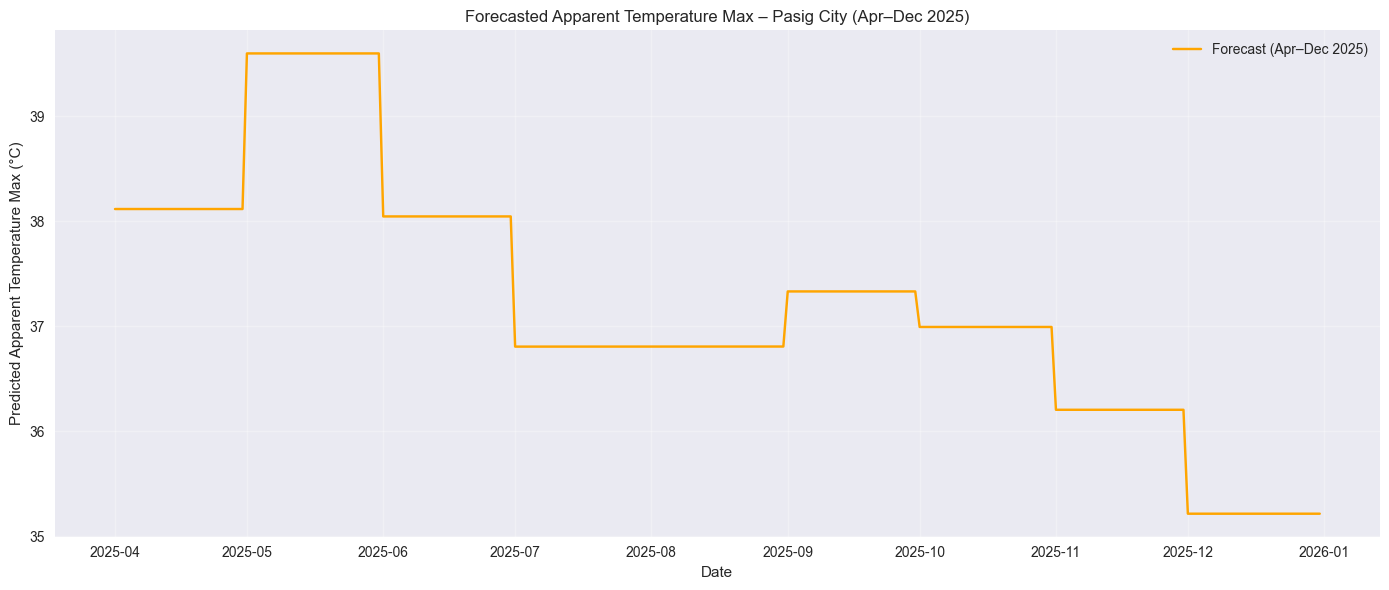

In [9]:
plt.figure(figsize=(14,6))
plt.plot(
    df_forecast["datetime"],
    df_forecast["predicted_apparent_temperature_max"],
    label="Forecast (Apr–Dec 2025)",
    color="orange"
)
plt.title("Forecasted Apparent Temperature Max – Pasig City (Apr–Dec 2025)")
plt.xlabel("Date")
plt.ylabel("Predicted Apparent Temperature Max (°C)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

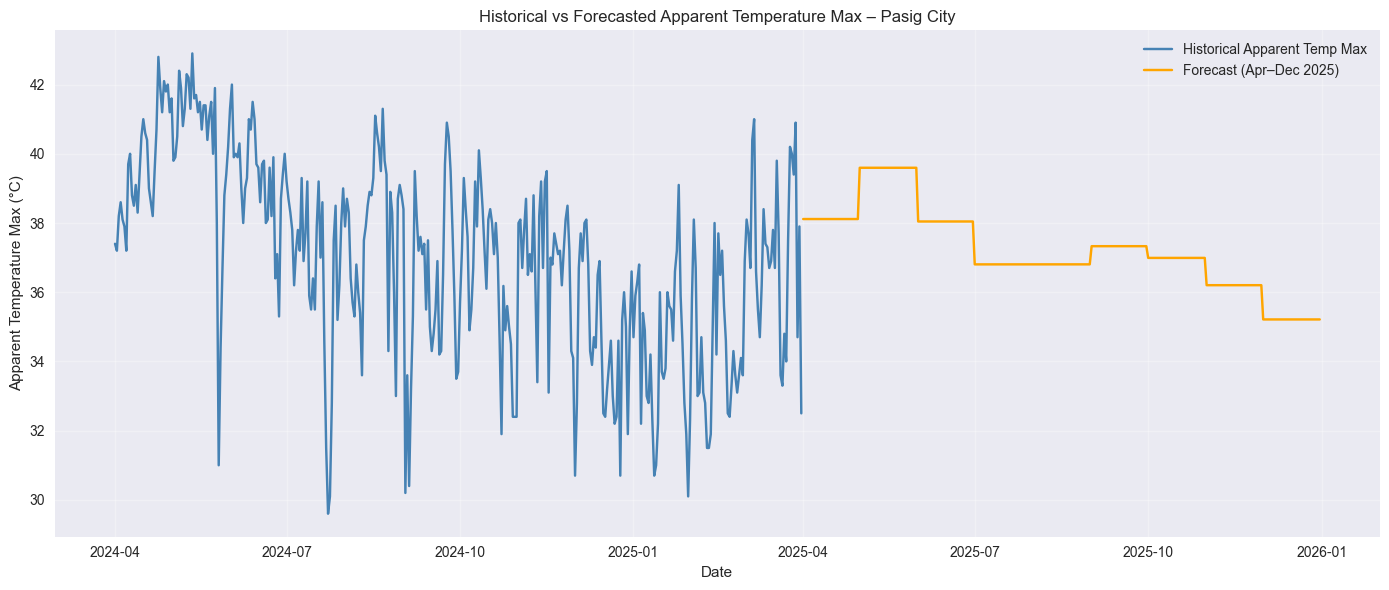

In [10]:
# Take last 12 months of history, e.g. from 2024-04-01
history_mask = df_model["datetime"] >= "2024-04-01"
df_history = df_model.loc[history_mask, ["datetime", "apparent_temperature_max"]]

plt.figure(figsize=(14,6))

# Historical
plt.plot(
    df_history["datetime"],
    df_history["apparent_temperature_max"],
    label="Historical Apparent Temp Max",
    color="steelblue"
)

# Forecast
plt.plot(
    df_forecast["datetime"],
    df_forecast["predicted_apparent_temperature_max"],
    label="Forecast (Apr–Dec 2025)",
    color="orange"
)

plt.title("Historical vs Forecasted Apparent Temperature Max – Pasig City")
plt.xlabel("Date")
plt.ylabel("Apparent Temperature Max (°C)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# Extract year & month
df_model["year"] = df_model["datetime"].dt.year
df_model["month"] = df_model["datetime"].dt.month

# Compute historical monthly average of the target variable
df_monthly_hist = (
    df_model.groupby(["year", "month"])["apparent_temperature_max"]
    .mean()
    .reset_index()
)

# Create a proper date column for plotting
df_monthly_hist["date"] = pd.to_datetime(
    df_monthly_hist["year"].astype(str) + "-" +
    df_monthly_hist["month"].astype(str) + "-01"
)

In [12]:
df_forecast["year"] = df_forecast["datetime"].dt.year
df_forecast["month"] = df_forecast["datetime"].dt.month

df_monthly_forecast = (
    df_forecast.groupby(["year", "month"])["predicted_apparent_temperature_max"]
    .mean()
    .reset_index()
)

# Create date column
df_monthly_forecast["date"] = pd.to_datetime(
    df_monthly_forecast["year"].astype(str) + "-" +
    df_monthly_forecast["month"].astype(str) + "-01"
)

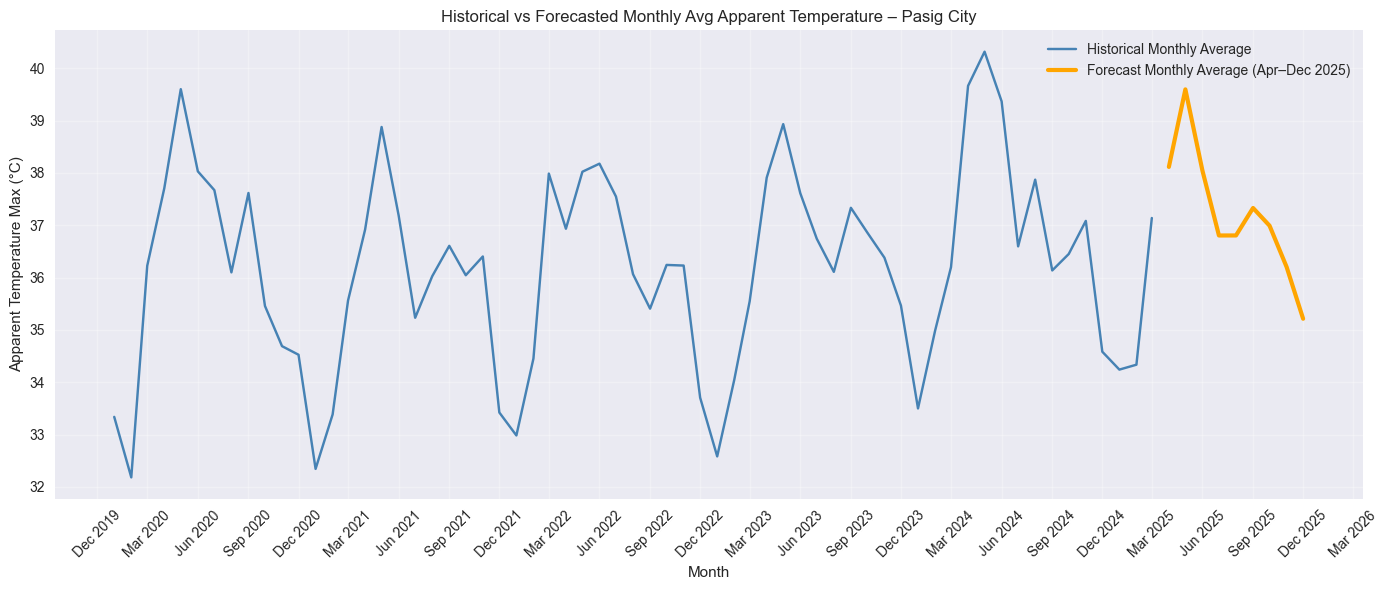

In [13]:
import matplotlib.dates as mdates

plt.figure(figsize=(14,6))

# Plot historical monthly average
plt.plot(
    df_monthly_hist["date"],
    df_monthly_hist["apparent_temperature_max"],
    label="Historical Monthly Average",
    color="steelblue"
)

# Plot forecast monthly average
plt.plot(
    df_monthly_forecast["date"],
    df_monthly_forecast["predicted_apparent_temperature_max"],
    label="Forecast Monthly Average (Apr–Dec 2025)",
    color="orange",
    linewidth=3
)

plt.title("Historical vs Forecasted Monthly Avg Apparent Temperature – Pasig City")
plt.xlabel("Month")
plt.ylabel("Apparent Temperature Max (°C)")
plt.grid(True, alpha=0.3)
plt.legend()

ax = plt.gca()

# Show one tick every 2 or 3 months (adjust interval)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # e.g., Jan 2020

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

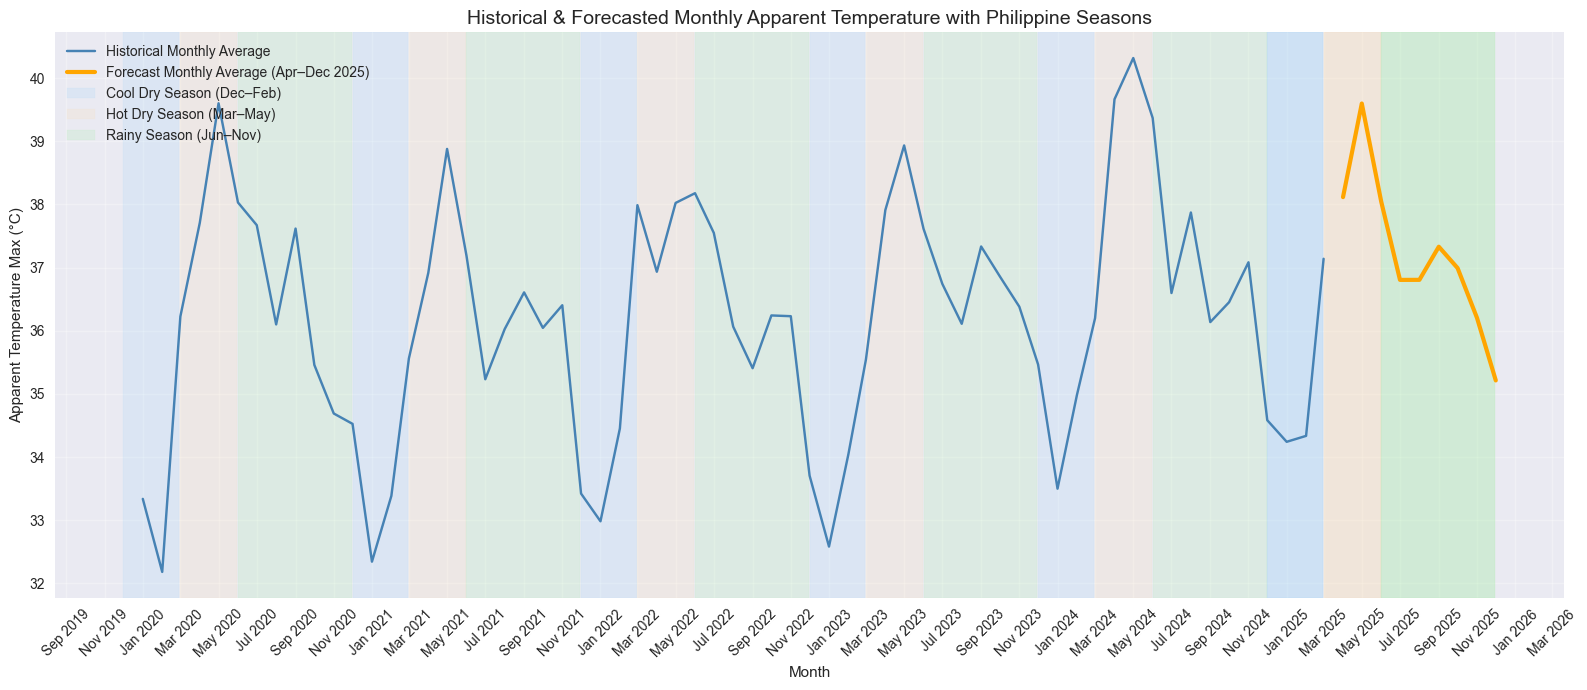

In [14]:
import matplotlib.dates as mdates
from datetime import datetime

plt.figure(figsize=(16,7))
ax = plt.gca()

# ----- Plot Historical -----
ax.plot(
    df_monthly_hist["date"],
    df_monthly_hist["apparent_temperature_max"],
    label="Historical Monthly Average",
    color="steelblue"
)

# ----- Plot Forecast -----
ax.plot(
    df_monthly_forecast["date"],
    df_monthly_forecast["predicted_apparent_temperature_max"],
    label="Forecast Monthly Average (Apr–Dec 2025)",
    color="orange",
    linewidth=3
)

# ----- Add Philippine Seasons -----
years = sorted(df_monthly_hist["year"].unique())
years.append(2025)   # include 2025

added_cool_label = False
added_hot_label = False
added_rain_label = False

for yr in years:

    # Cool Dry Season: Dec 1 – Feb 28/29
    cool_start = datetime(yr-1, 12, 1)   # Dec of previous year
    cool_end   = datetime(yr, 2, 28)
    ax.axvspan(
        cool_start, cool_end,
        color="lightskyblue", alpha=0.15,
        label="Cool Dry Season (Dec–Feb)" if not added_cool_label else None
    )
    added_cool_label = True

    # Hot Dry Season: Mar 1 – May 31
    hot_start = datetime(yr, 3, 1)
    hot_end   = datetime(yr, 5, 31)
    ax.axvspan(
        hot_start, hot_end,
        color="navajowhite", alpha=0.18,
        label="Hot Dry Season (Mar–May)" if not added_hot_label else None
    )
    added_hot_label = True

    # Rainy Season: Jun 1 – Nov 30
    rain_start = datetime(yr, 6, 1)
    rain_end   = datetime(yr, 11, 30)
    ax.axvspan(
        rain_start, rain_end,
        color="lightgreen", alpha=0.15,
        label="Rainy Season (Jun–Nov)" if not added_rain_label else None
    )
    added_rain_label = True

# ----- Formatting -----
ax.set_title("Historical & Forecasted Monthly Apparent Temperature with Philippine Seasons", fontsize=14)
ax.set_xlabel("Month")
ax.set_ylabel("Apparent Temperature Max (°C)")
ax.grid(True, alpha=0.3)

# Month/Year on x-axis
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)

plt.legend()
plt.tight_layout()
plt.show()

## Forecasting 2026

In [15]:
future_dates_2026 = pd.date_range(start="2026-01-01", end="2026-12-31", freq="D")

In [16]:
future_rows_2026 = []

for dt in future_dates_2026:
    m = dt.month
    avg_row = monthly_feature_means.loc[m].copy()
    avg_row["month"] = m
    future_rows_2026.append(avg_row)

X_future_2026 = pd.DataFrame(future_rows_2026, index=future_dates_2026)

In [17]:
y_future_2026 = rf_model.predict(X_future_2026[feature_names])

df_forecast_2026 = pd.DataFrame({
    "datetime": future_dates_2026,
    "predicted_apparent_temperature_max": y_future_2026
})

In [18]:
df_forecast_2026["year"] = df_forecast_2026["datetime"].dt.year
df_forecast_2026["month"] = df_forecast_2026["datetime"].dt.month

df_monthly_forecast_2026 = (
    df_forecast_2026.groupby(["year", "month"])["predicted_apparent_temperature_max"]
    .mean()
    .reset_index()
)

df_monthly_forecast_2026["date"] = pd.to_datetime(
    df_monthly_forecast_2026["year"].astype(str) + "-" +
    df_monthly_forecast_2026["month"].astype(str) + "-01"
)

In [19]:
df_monthly_forecast_all = pd.concat(
    [df_monthly_forecast, df_monthly_forecast_2026],
    ignore_index=True
)

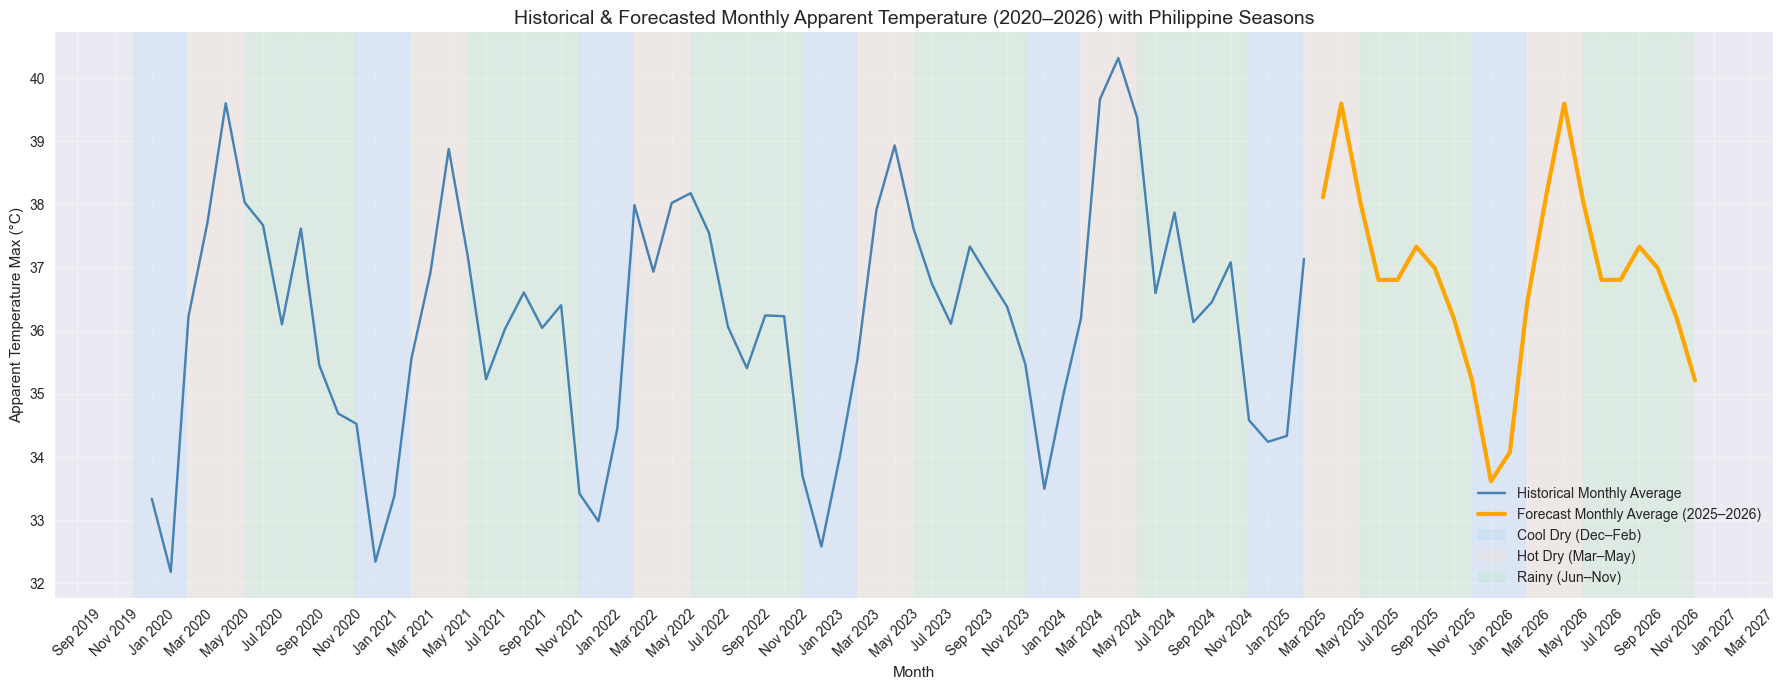

In [20]:
import matplotlib.dates as mdates
from datetime import datetime

plt.figure(figsize=(18,7))
ax = plt.gca()

# ---------- Historical ----------
ax.plot(
    df_monthly_hist["date"],
    df_monthly_hist["apparent_temperature_max"],
    label="Historical Monthly Average",
    color="steelblue"
)

# ---------- Forecast 2025–2026 ----------
ax.plot(
    df_monthly_forecast_all["date"],
    df_monthly_forecast_all["predicted_apparent_temperature_max"],
    label="Forecast Monthly Average (2025–2026)",
    color="orange",
    linewidth=3
)

# ---------- Philippine Seasons ----------
years = list(range(2020, 2027))  # include historical + forecast years

added_cool = added_hot = added_rain = False

for yr in years:

    # COOL DRY: Dec (yr-1) → Feb (yr)
    ax.axvspan(datetime(yr-1, 12, 1), datetime(yr, 2, 28),
               color="lightskyblue", alpha=0.15,
               label="Cool Dry (Dec–Feb)" if not added_cool else None)
    added_cool = True

    # HOT DRY: Mar–May
    ax.axvspan(datetime(yr, 3, 1), datetime(yr, 5, 31),
               color="navajowhite", alpha=0.18,
               label="Hot Dry (Mar–May)" if not added_hot else None)
    added_hot = True

    # RAINY: Jun–Nov
    ax.axvspan(datetime(yr, 6, 1), datetime(yr, 11, 30),
               color="lightgreen", alpha=0.15,
               label="Rainy (Jun–Nov)" if not added_rain else None)
    added_rain = True

# ---------- Formatting ----------
ax.set_title("Historical & Forecasted Monthly Apparent Temperature (2020–2026) with Philippine Seasons", fontsize=14)
ax.set_xlabel("Month")
ax.set_ylabel("Apparent Temperature Max (°C)")
ax.grid(True, alpha=0.3)

# X-axis formatting
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)

plt.legend()
plt.tight_layout()
plt.show()
